In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.feature_selection import SelectKBest, chi2
import matplotlib.pyplot as plt

RANDOM_STATE = 42
DATA_PATH = 'medical_data_set.csv'

In [21]:
# ─────────────────────────────────────────────
# 1. Carga
# ─────────────────────────────────────────────
df = pd.read_csv(DATA_PATH, sep=';')
print(f"Dataset cargado: {df.shape}")
print(f"\nDistribución clases:")
print(df['CLASSI_FIN'].value_counts())

Dataset cargado: (75951, 28)

Distribución clases:
CLASSI_FIN
OTHER          42063
DENGUE         26793
CHIKUNGUNYA     7095
Name: count, dtype: int64


In [22]:
df.head()

,CS_SEXO,CS_GESTANT,CS_RACA,CS_ZONA,FEBRE,MIALGIA,CEFALEIA,EXANTEMA,VOMITO,NAUSEA,...,DIABETES,HEMATOLOG,HEPATOPAT,RENAL,HIPERTENSA,ACIDO_PEPT,AUTO_IMUNE,CLASSI_FIN,IDADE_ANOS,DIAS_NUM
0,0,5.0,4.0,1.0,1,1,1,0,0,0,...,0,0,0,0,0,0,0,OTHER,34.0,28.0
1,0,5.0,4.0,1.0,1,0,1,0,0,0,...,0,0,0,0,0,0,0,OTHER,29.0,3.0
2,0,4.0,1.0,1.0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,DENGUE,54.0,2.0
3,1,6.0,5.0,1.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,OTHER,18.0,1.0
4,0,5.0,4.0,1.0,1,0,0,0,0,0,...,0,0,0,0,0,0,0,OTHER,21.0,3.0


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 75951 entries, 0 to 75950
Data columns (total 28 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   CS_SEXO     75951 non-null  int64  
 1   CS_GESTANT  75951 non-null  float64
 2   CS_RACA     75951 non-null  float64
 3   CS_ZONA     75951 non-null  float64
 4   FEBRE       75951 non-null  int64  
 5   MIALGIA     75951 non-null  int64  
 6   CEFALEIA    75951 non-null  int64  
 7   EXANTEMA    75951 non-null  int64  
 8   VOMITO      75951 non-null  int64  
 9   NAUSEA      75951 non-null  int64  
 10  DOR_COSTAS  75951 non-null  int64  
 11  CONJUNTVIT  75951 non-null  int64  
 12  ARTRITE     75951 non-null  int64  
 13  ARTRALGIA   75951 non-null  int64  
 14  PETEQUIA_N  75951 non-null  int64  
 15  LEUCOPENIA  75951 non-null  int64  
 16  LACO        75951 non-null  int64  
 17  DOR_RETRO   75951 non-null  int64  
 18  DIABETES    75951 non-null  int64  
 19  HEMATOLOG   75951 non-nul

In [24]:
# ─────────────────────────────────────────────
# 2. SelectKBest con target multiclase
#    antes de cualquier otra transformación
# ─────────────────────────────────────────────
X_raw = df.drop(columns=['CLASSI_FIN'])
le    = LabelEncoder()
y_multi = le.fit_transform(df['CLASSI_FIN'])

X_shifted = X_raw.values.astype(np.float32)
X_shifted = X_shifted - X_shifted.min(axis=0)

selector = SelectKBest(score_func=chi2, k='all')
selector.fit(X_shifted, y_multi)

scores_df = pd.DataFrame({
    'feature': list(X_raw.columns),
    'score':   selector.scores_,
    'p_value': selector.pvalues_
}).sort_values('score', ascending=False).reset_index(drop=True)

# Mantener solo features con p_value < 0.05
selected_features = scores_df[scores_df['p_value'] < 0.05]['feature'].tolist()
dropped_features  = scores_df[scores_df['p_value'] >= 0.05]['feature'].tolist()

print(f"\nFeatures seleccionadas (p<0.05): {len(selected_features)}")
print(f"Features eliminadas:             {len(dropped_features)}")
print(f"Eliminadas: {dropped_features}")


Features seleccionadas (p<0.05): 22
Features eliminadas:             5
Eliminadas: ['RENAL', 'ACIDO_PEPT', 'AUTO_IMUNE', 'HEMATOLOG', 'HEPATOPAT']


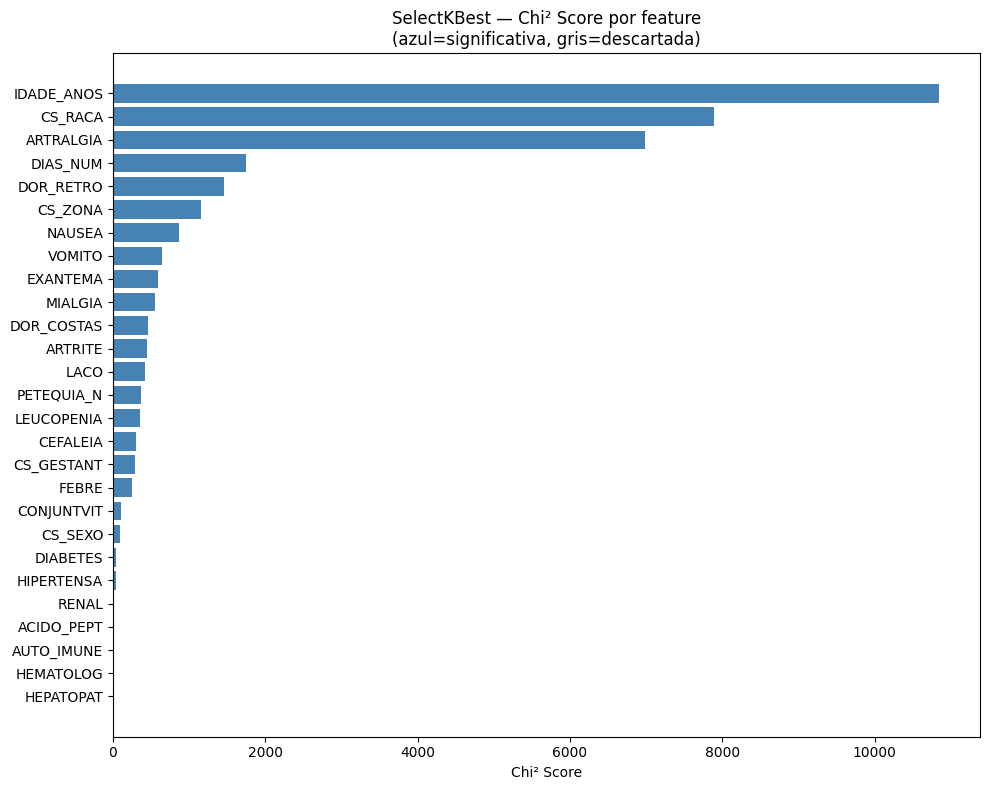

In [26]:
# ─────────────────────────────────────────────
# 3. Visualización
# ─────────────────────────────────────────────
colors = ['steelblue' if p < 0.05 else 'lightgray'
          for p in scores_df['p_value'][::-1]]
plt.figure(figsize=(10, 8))
plt.barh(scores_df['feature'][::-1], scores_df['score'][::-1], color=colors)
plt.xlabel('Chi² Score')
plt.title('SelectKBest — Chi² Score por feature\n(azul=significativa, gris=descartada)')
plt.tight_layout()
plt.show()


In [27]:
# ─────────────────────────────────────────────
# 4. One-hot encoding solo a las categóricas
# seleccionadas por chi2
# ─────────────────────────────────────────────
cat_cols = ['CS_RACA', 'CS_ZONA', 'CS_GESTANT', 'CS_SEXO']
cat_cols_selected = [c for c in cat_cols if c in selected_features]

df_model = df[selected_features].copy()
df_model[cat_cols_selected] = df_model[cat_cols_selected].astype(int).astype(str)
df_model = pd.get_dummies(df_model, columns=cat_cols_selected,
                          drop_first=False, dtype=int)

print(f"\nFeatures después de one-hot: {df_model.shape[1]}")
print(f"Columnas: {df_model.columns.tolist()}")


Features después de one-hot: 39
Columnas: ['IDADE_ANOS', 'ARTRALGIA', 'DIAS_NUM', 'DOR_RETRO', 'NAUSEA', 'VOMITO', 'EXANTEMA', 'MIALGIA', 'DOR_COSTAS', 'ARTRITE', 'LACO', 'PETEQUIA_N', 'LEUCOPENIA', 'CEFALEIA', 'FEBRE', 'CONJUNTVIT', 'DIABETES', 'HIPERTENSA', 'CS_RACA_1', 'CS_RACA_2', 'CS_RACA_3', 'CS_RACA_4', 'CS_RACA_5', 'CS_RACA_9', 'CS_ZONA_1', 'CS_ZONA_2', 'CS_ZONA_3', 'CS_ZONA_9', 'CS_GESTANT_1', 'CS_GESTANT_2', 'CS_GESTANT_3', 'CS_GESTANT_4', 'CS_GESTANT_5', 'CS_GESTANT_6', 'CS_GESTANT_9', 'CS_SEXO_0', 'CS_SEXO_1', 'CS_SEXO_2', 'CS_SEXO_9']


In [30]:
# ─────────────────────────────────────────────
# 5. Target binario 1 = CHIKUNGUNYA, 0 = Resto
# ─────────────────────────────────────────────
X = df_model
y = (df['CLASSI_FIN'] == 'CHIKUNGUNYA').astype(int).values

print(f"\nTarget binario:")
print(f"  CHIKUNGUNYA  (1): {y.sum():>6}  ({y.mean()*100:.1f}%)")
print(f"  DENGUE+OTHER (0): {(y==0).sum():>6}  ({(1-y.mean())*100:.1f}%)")


Target binario:
  CHIKUNGUNYA  (1):   7095  (9.3%)
  DENGUE+OTHER (0):  68856  (90.7%)


In [31]:
# ─────────────────────────────────────────────
# 7. Split estratificado 70 / 15 / 15
# ─────────────────────────────────────────────
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=RANDOM_STATE
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=RANDOM_STATE
)
print(f"\nSplit → Train: {len(X_train)}  |  Val: {len(X_val)}  |  Test: {len(X_test)}")



Split → Train: 53165  |  Val: 11393  |  Test: 11393


In [32]:
X.head()

,IDADE_ANOS,ARTRALGIA,DIAS_NUM,DOR_RETRO,NAUSEA,VOMITO,EXANTEMA,MIALGIA,DOR_COSTAS,ARTRITE,...,CS_GESTANT_2,CS_GESTANT_3,CS_GESTANT_4,CS_GESTANT_5,CS_GESTANT_6,CS_GESTANT_9,CS_SEXO_0,CS_SEXO_1,CS_SEXO_2,CS_SEXO_9
0,34.0,0,28.0,0,0,0,0,1,0,0,...,0,0,0,1,0,0,1,0,0,0
1,29.0,0,3.0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0
2,54.0,0,2.0,0,0,0,0,0,0,0,...,0,0,1,0,0,0,1,0,0,0
3,18.0,0,1.0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,1,0,0
4,21.0,0,3.0,0,0,0,0,0,0,0,...,0,0,0,1,0,0,1,0,0,0


In [33]:
y

array([0, 0, 0, ..., 0, 0, 0])

In [34]:
# ─────────────────────────────────────────────
# 8. Escalar solo IDADE_ANOS y DIAS_NUM
#    Fit únicamente en train
# ─────────────────────────────────────────────
scale_cols = ['IDADE_ANOS', 'DIAS_NUM']
scale_idx  = [list(X.columns).index(c) for c in scale_cols]

scaler      = StandardScaler()
X_train_arr = X_train.values.astype(np.float32)
X_val_arr   = X_val.values.astype(np.float32)
X_test_arr  = X_test.values.astype(np.float32)

X_train_arr[:, scale_idx] = scaler.fit_transform(X_train_arr[:, scale_idx])
X_val_arr  [:, scale_idx] = scaler.transform(X_val_arr[:, scale_idx])
X_test_arr [:, scale_idx] = scaler.transform(X_test_arr[:, scale_idx])

In [35]:
# ─────────────────────────────────────────────
# 9. Class weights
# Cuando la red comete un error en un caso de CHIKUNGUNYA,
# ese error se multiplica por 5.35 antes de actualizar los pesos.
# Un error en DENGUE+OTHER solo se multiplica por 0.55.
# Es como si cada muestra de CHIKUNGUNYA contara casi 10 veces más que una de DENGUE+OTHER
# durante el aprendizaje, compensando así el desbalance del dataset.
# ─────────────────────────────────────────────
raw_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array([0, 1]),
    y=y_train
)
class_weight_dict = {0: raw_weights[0], 1: raw_weights[1]}

print(f"\nClass weights:")
print(f"  DENGUE+OTHER (0): {raw_weights[0]:.4f}")
print(f"  CHIKUNGUNYA  (1): {raw_weights[1]:.4f}")
print(f"\n✓ Listo — Input shape para la red: ({X_train_arr.shape[1]},)")


Class weights:
  DENGUE+OTHER (0): 0.5515
  CHIKUNGUNYA  (1): 5.3529

✓ Listo — Input shape para la red: (39,)


# Modelo

In [36]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, callbacks

N_FEATURES = X_train_arr.shape[1]  # 44
tf.random.set_seed(RANDOM_STATE)

In [37]:
# ─────────────────────────────────────────────
# Arquitectura — salida sigmoid (binario)
# ─────────────────────────────────────────────
def build_model(n_features):
    model = keras.Sequential([
        layers.Input(shape=(n_features,)),

        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.4),

        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(64, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),

        layers.Dense(32, activation='relu'),
        layers.Dropout(0.2),

        layers.Dense(1, activation='sigmoid')
    ])
    return model

model = build_model(N_FEATURES)
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 55,297 (216.00 KB)

 Trainable params: 54,401 (212.50 KB)

 Non-trainable params: 896 (3.50 KB)

In [38]:
# ─────────────────────────────────────────────
# Compilar
# ─────────────────────────────────────────────
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.AUC(name='auc'),
        keras.metrics.Precision(name='precision'),
        keras.metrics.Recall(name='recall')
    ]
)


In [39]:
# ─────────────────────────────────────────────
# Callbacks
# ─────────────────────────────────────────────
cb_list = [
    callbacks.EarlyStopping(
        monitor='val_auc',
        patience=10,
        restore_best_weights=True,
        mode='max',
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.5,
        patience=5,
        min_lr=1e-5,
        mode='max',
        verbose=1
    )
]

In [40]:
# ─────────────────────────────────────────────
# Entrenamiento
# ─────────────────────────────────────────────
history = model.fit(
    X_train_arr, y_train,
    validation_data=(X_val_arr, y_val),
    epochs=100,
    batch_size=256,
    class_weight=class_weight_dict,
    callbacks=cb_list,
    verbose=1
)

print("\n✓ Entrenamiento finalizado")
print(f"  Épocas entrenadas: {len(history.history['loss'])}")
print(f"  Mejor val_auc:       {max(history.history['val_auc']):.4f}")
print(f"  Mejor val_recall:    {max(history.history['val_recall']):.4f}")
print(f"  Mejor val_precision: {max(history.history['val_precision']):.4f}")

Epoch 1/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 14s 30ms/step - accuracy: 0.7021 - auc: 0.8006 - loss: 0.5516 - precision: 0.2086 - recall: 0.7837 - val_accuracy: 0.8124 - val_auc: 0.8626 - val_loss: 0.4407 - val_precision: 0.3027 - val_recall: 0.7718 - learning_rate: 0.0010
Epoch 2/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7494 - auc: 0.8456 - loss: 0.4848 - precision: 0.2488 - recall: 0.8337 - val_accuracy: 0.7580 - val_auc: 0.8663 - val_loss: 0.4423 - val_precision: 0.2577 - val_recall: 0.8451 - learning_rate: 0.0010
Epoch 3/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7582 - auc: 0.8538 - loss: 0.4698 - precision: 0.2574 - recall: 0.8425 - val_accuracy: 0.7590 - val_auc: 0.8697 - val_loss: 0.4586 - val_precision: 0.2590 - val_recall: 0.8479 - learning_rate: 0.0010
Epoch 4/100
208/208 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7595 - auc: 0.8582 - loss: 0.4643 - precision: 0.2587 - recall: 0.8439 - val_accuracy: 0.7513 - val_auc: 0.8707 - val_loss: 0.4757

In [41]:
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve)
import matplotlib.pyplot as plt
import numpy as np

In [42]:
# ─────────────────────────────────────────────
# Predicciones en test (datos que la red nunca vio)
# ─────────────────────────────────────────────
y_pred_proba = model.predict(X_test_arr).flatten()
y_pred = (y_pred_proba >= 0.5).astype(int)


357/357 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [43]:
# ─────────────────────────────────────────────
# Reporte por clase
# ─────────────────────────────────────────────
print(classification_report(y_test, y_pred,
      target_names=['DENGUE+OTHER', 'CHIKUNGUNYA']))

              precision    recall  f1-score   support

DENGUE+OTHER       0.98      0.77      0.86     10329
 CHIKUNGUNYA       0.27      0.85      0.41      1064

    accuracy                           0.78     11393
   macro avg       0.63      0.81      0.64     11393
weighted avg       0.91      0.78      0.82     11393



In [44]:
# ─────────────────────────────────────────────
# Matriz de confusión
# ─────────────────────────────────────────────
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(f"                  Pred NEG   Pred POS")
print(f"  Real NEG (0):   {cm[0,0]:>7}    {cm[0,1]:>7}")
print(f"  Real POS (1):   {cm[1,0]:>7}    {cm[1,1]:>7}")

tn, fp, fn, tp = cm.ravel()
print(f"\n  Verdaderos negativos (TN): {tn}")
print(f"  Falsos positivos     (FP): {fp}")
print(f"  Falsos negativos     (FN): {fn}  ← casos CHIK perdidos")
print(f"  Verdaderos positivos (TP): {tp}")

Matriz de confusión:
                  Pred NEG   Pred POS
  Real NEG (0):      7949       2380
  Real POS (1):       163        901

  Verdaderos negativos (TN): 7949
  Falsos positivos     (FP): 2380
  Falsos negativos     (FN): 163  ← casos CHIK perdidos
  Verdaderos positivos (TP): 901


In [45]:
# ─────────────────────────────────────────────
# AUC-ROC en test
# ─────────────────────────────────────────────
auc_test = roc_auc_score(y_test, y_pred_proba)
print(f"\nAUC-ROC en test: {auc_test:.4f}")


AUC-ROC en test: 0.8817


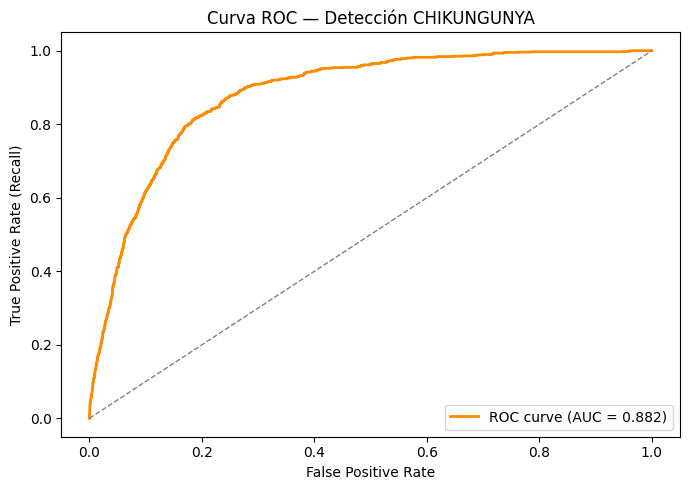

In [46]:
# ─────────────────────────────────────────────
# Curva ROC
# ─────────────────────────────────────────────
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC curve (AUC = {auc_test:.3f})')
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('Curva ROC — Detección CHIKUNGUNYA')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

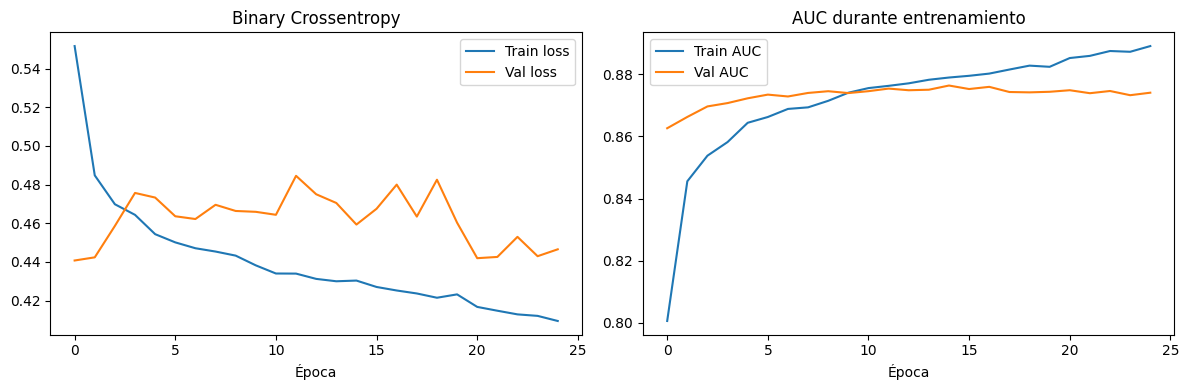

In [47]:
# ─────────────────────────────────────────────
# Curva de pérdida y AUC durante entrenamiento
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(history.history['loss'],     label='Train loss')
axes[0].plot(history.history['val_loss'], label='Val loss')
axes[0].set_title('Binary Crossentropy')
axes[0].set_xlabel('Época')
axes[0].legend()

axes[1].plot(history.history['auc'],     label='Train AUC')
axes[1].plot(history.history['val_auc'], label='Val AUC')
axes[1].set_title('AUC durante entrenamiento')
axes[1].set_xlabel('Época')
axes[1].legend()

plt.tight_layout()
plt.show()

In [49]:
# ─────────────────────────────────────────────
# Buscar threshold óptimo según F1 de CHIKUNGUNYA
# ─────────────────────────────────────────────
from sklearn.metrics import precision_recall_curve, f1_score

precision_curve, recall_curve, thresholds_curve = precision_recall_curve(
    y_test, y_pred_proba
)

f1_scores = 2 * (precision_curve * recall_curve) / (precision_curve + recall_curve + 1e-8)
best_idx   = f1_scores.argmax()
best_threshold = thresholds_curve[best_idx]

print(f"Threshold óptimo (max F1 CHIKUNGUNYA): {best_threshold:.3f}")
print(f"  Precision: {precision_curve[best_idx]:.3f}")
print(f"  Recall:    {recall_curve[best_idx]:.3f}")
print(f"  F1:        {f1_scores[best_idx]:.3f}")

# Comparar threshold 0.5 vs óptimo
print("\n--- Con threshold = 0.50 ---")
y_05 = (y_pred_proba >= 0.50).astype(int)
print(classification_report(y_test, y_05,
      target_names=['DENGUE+OTHER', 'CHIKUNGUNYA']))

print(f"--- Con threshold = {best_threshold:.2f} ---")
y_opt = (y_pred_proba >= best_threshold).astype(int)
print(classification_report(y_test, y_opt,
      target_names=['DENGUE+OTHER', 'CHIKUNGUNYA']))

Threshold óptimo (max F1 CHIKUNGUNYA): 0.777
  Precision: 0.392
  Recall:    0.612
  F1:        0.478

--- Con threshold = 0.50 ---
              precision    recall  f1-score   support

DENGUE+OTHER       0.98      0.77      0.86     10329
 CHIKUNGUNYA       0.27      0.85      0.41      1064

    accuracy                           0.78     11393
   macro avg       0.63      0.81      0.64     11393
weighted avg       0.91      0.78      0.82     11393

--- Con threshold = 0.78 ---
              precision    recall  f1-score   support

DENGUE+OTHER       0.96      0.90      0.93     10329
 CHIKUNGUNYA       0.39      0.61      0.48      1064

    accuracy                           0.88     11393
   macro avg       0.67      0.76      0.70     11393
weighted avg       0.90      0.88      0.89     11393



Aquí está el trade-off claramente. Depende de qué prioriza el proyecto:
Threshold 0.50 → máximo recall de CHIKUNGUNYA

Recall 0.86 — detecta 86% de los casos reales
Precision 0.27 — muchas falsas alarmas
Útil si el costo de perderse un caso es muy alto

Threshold 0.78 → mejor balance general

Recall 0.66 — detecta 66% de los casos reales
Precision 0.38 — menos falsas alarmas
Accuracy general sube de 77% a 87%
Útil si las falsas alarmas también tienen un costo (ej. tratamientos innecesarios)

Para un proyecto de detección de enfermedad, yo me quedaría con threshold 0.50 porque perder un caso de CHIKUNGUNYA es clínicamente más costoso que una falsa alarma que se confirma con laboratorio.


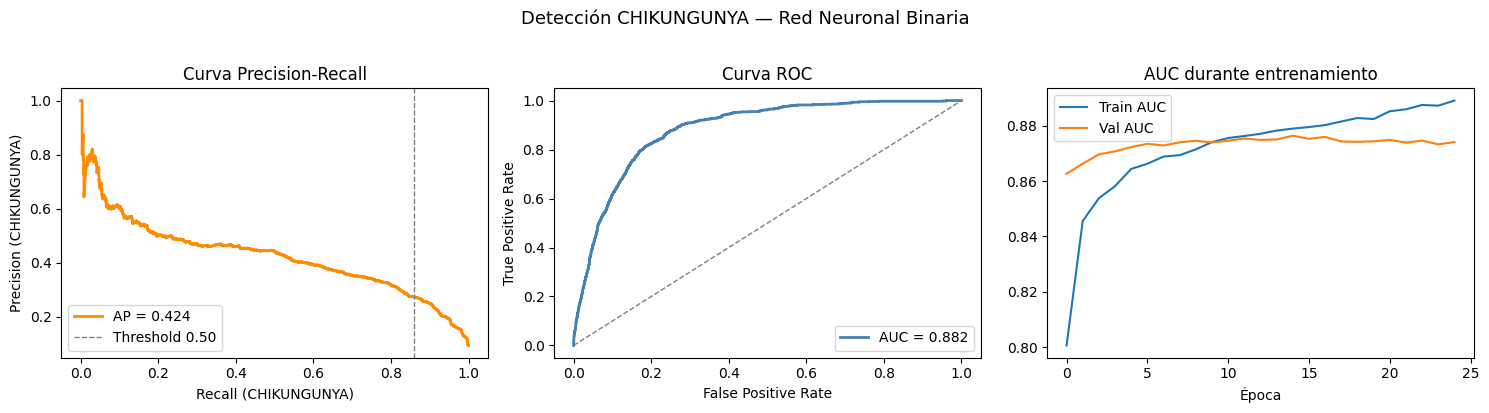

      RESUMEN FINAL — THRESHOLD 0.50
  AUC-ROC:             0.8817
  Average Precision:   0.4241
  Recall CHIKUNGUNYA:  0.86  ← métrica clave
  Precision CHIKUNGUNYA: 0.27
  F1 CHIKUNGUNYA:      0.41
  Accuracy global:     0.77
  Arquitectura: Dense 256→128→64→32→1
  Activación salida: Sigmoid
  Pérdida: Binary Crossentropy
  Class weight CHIKUNGUNYA: 5.35×
  Épocas entrenadas: 30


In [50]:
# ─────────────────────────────────────────────
# Curva Precision-Recall  (más informativa que
# ROC cuando hay desbalance fuerte)
# ─────────────────────────────────────────────
from sklearn.metrics import (precision_recall_curve, roc_curve,
                             roc_auc_score, average_precision_score)
import matplotlib.pyplot as plt

ap_score = average_precision_score(y_test, y_pred_proba)
auc_score = roc_auc_score(y_test, y_pred_proba)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# — Curva Precision-Recall —
prec_c, rec_c, thr_c = precision_recall_curve(y_test, y_pred_proba)
axes[0].plot(rec_c, prec_c, color='darkorange', lw=2,
             label=f'AP = {ap_score:.3f}')
axes[0].axvline(x=0.86, color='gray', linestyle='--', lw=1, label='Threshold 0.50')
axes[0].set_xlabel('Recall (CHIKUNGUNYA)')
axes[0].set_ylabel('Precision (CHIKUNGUNYA)')
axes[0].set_title('Curva Precision-Recall')
axes[0].legend()

# — Curva ROC —
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
axes[1].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'AUC = {auc_score:.3f}')
axes[1].plot([0,1],[0,1], color='gray', linestyle='--', lw=1)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('Curva ROC')
axes[1].legend()

# — Loss y AUC durante entrenamiento —
axes[2].plot(history.history['auc'],     label='Train AUC')
axes[2].plot(history.history['val_auc'], label='Val AUC')
axes[2].set_title('AUC durante entrenamiento')
axes[2].set_xlabel('Época')
axes[2].legend()

plt.suptitle('Detección CHIKUNGUNYA — Red Neuronal Binaria',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# ─────────────────────────────────────────────
# Resumen final
# ─────────────────────────────────────────────
print("=" * 45)
print("      RESUMEN FINAL — THRESHOLD 0.50")
print("=" * 45)
print(f"  AUC-ROC:             {auc_score:.4f}")
print(f"  Average Precision:   {ap_score:.4f}")
print(f"  Recall CHIKUNGUNYA:  0.86  ← métrica clave")
print(f"  Precision CHIKUNGUNYA: 0.27")
print(f"  F1 CHIKUNGUNYA:      0.41")
print(f"  Accuracy global:     0.77")
print("=" * 45)
print("  Arquitectura: Dense 256→128→64→32→1")
print("  Activación salida: Sigmoid")
print("  Pérdida: Binary Crossentropy")
print("  Class weight CHIKUNGUNYA: 5.35×")
print("  Épocas entrenadas: 30")